# Linear Transformations - Lab

## Introduction

In this lab, you'll practice your linear transformation skills!

## Objectives

You will be able to:

* Determine if a linear transformation would be useful for a specific model or set of data
* Identify an appropriate linear transformation technique for a specific model or set of data
* Apply linear transformations to independent and dependent variables in linear regression
* Interpret the coefficients of variables that have been transformed using a linear transformation

## Ames Housing Data

Let's look at the Ames Housing data, where each record represents a home sale:

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

ames = pd.read_csv('ames.csv', index_col=0)
ames

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


We'll use this subset of features. These are specifically the _continuous numeric_ variables, which means that we'll hopefully have meaningful mean values.

From the data dictionary (`data_description.txt`):

```
LotArea: Lot size in square feet

MasVnrArea: Masonry veneer area in square feet

TotalBsmtSF: Total square feet of basement area

GrLivArea: Above grade (ground) living area square feet

GarageArea: Size of garage in square feet
```

In [4]:
ames = ames[[
    "LotArea",
    "MasVnrArea",
    "TotalBsmtSF",
    "GrLivArea",
    "GarageArea",
    "SalePrice"
]].copy()
ames

,LotArea,MasVnrArea,TotalBsmtSF,GrLivArea,GarageArea,SalePrice
Id,,,,,,
1,8450,196.0,856,1710,548,208500
2,9600,0.0,1262,1262,460,181500
3,11250,162.0,920,1786,608,223500
4,9550,0.0,756,1717,642,140000
5,14260,350.0,1145,2198,836,250000
...,...,...,...,...,...,...
1456,7917,0.0,953,1647,460,175000
1457,13175,119.0,1542,2073,500,210000
1458,9042,0.0,1152,2340,252,266500


We'll also drop any records with missing values for any of these features:

In [5]:
ames.dropna(how='any',inplace=True)
ames

,LotArea,MasVnrArea,TotalBsmtSF,GrLivArea,GarageArea,SalePrice
Id,,,,,,
1,8450,196.0,856,1710,548,208500
2,9600,0.0,1262,1262,460,181500
3,11250,162.0,920,1786,608,223500
4,9550,0.0,756,1717,642,140000
5,14260,350.0,1145,2198,836,250000
...,...,...,...,...,...,...
1456,7917,0.0,953,1647,460,175000
1457,13175,119.0,1542,2073,500,210000
1458,9042,0.0,1152,2340,252,266500


And plot the distributions of the un-transformed variables:

array([[<Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'MasVnrArea'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': 'GrLivArea'}>],
       [<Axes: title={'center': 'GarageArea'}>,
        <Axes: title={'center': 'SalePrice'}>]], dtype=object)

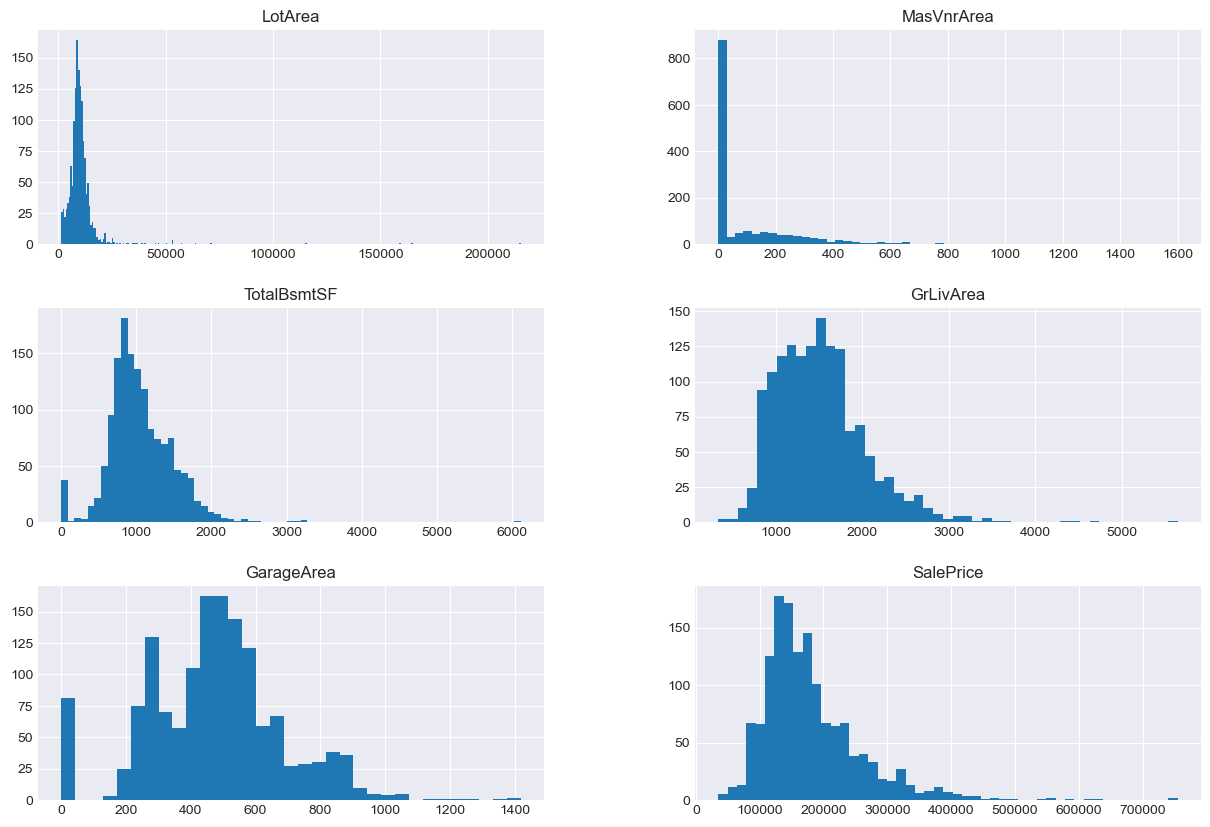

In [6]:
ames.hist(figsize=(15,10), bins="auto")
          

## Step 1: Build an Initial Linear Regression Model

`SalePrice` should be the target, and all other columns in `ames` should be predictors.

In [7]:
# Your code here - build a linear regression model with un-transformed features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = ames.drop(columns='SalePrice')
y = ames['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Initial_model = LinearRegression()
Initial_model.fit(X_train, y_train)





LinearRegression()

## Step 2: Evaluate Initial Model and Interpret Coefficients

Describe the model performance overall and interpret the meaning of each predictor coefficient. Make sure to refer to the explanations of what each feature means from the data dictionary!

In [19]:
# Your written answer here-evaluate the initial model
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
results = sm.OLS(y_train, X_train_sm).fit()
results.summary()




<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     448.5
Date:                Wed, 30 Apr 2025   Prob (F-statistic):          1.42e-267
Time:                        14:47:04   Log-Likelihood:                -14122.
No. Observations:                1161   AIC:                         2.826e+04
Df Residuals:                    1155   BIC:                         2.829e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.081e+04   4776.326     -2.263      0.024   -2.02e+04   -1435.238
LotArea         0.2492      0.131      1.907      0.057      -0.007       0.506
MasVnrArea     58.0481      8.613      6.739      0.000      41.149      74.948
TotalBsmtSF    39.9157      3.814     10.466      0.000      32.433      47.399
GrLivArea      62.6753      3.152     19.886      0.000      56.491      68.859
GarageArea     96.0066      7.792     12.321      0.000      80.719     111.294
==============================================================================
Omnibus:                      663.787   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            58746.148
Skew:                          -1.743   Prob(JB):                         0.00
Kurtosis:                      37.673   Cond. No.                     5.39e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.39e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The model overall is statistically significant and explains about 66% of the variance in sale price.

The coefficients are all statistically significant since the p_value are below 0.005.

* `LotArea`: for each additional square foot of lot area, the price increases by about \\$0.24
* `MasVnrArea`: for each additional square foot of masonry veneer, the price increases by about \\$58
* `TotalBsmtSF`: for each additional square foot of basement area, the price increases by about \\$40
* `GrLivArea`: for each additional square foot of above-grade living area, the price increases by about \\$63
* `GarageArea`: for each additional square foot of garage area, the price increases by about \\$96

<details>
    <summary style="cursor: pointer"><b>Answer (click to reveal)</b></summary>

The model overall is statistically significant and explains about 68% of the variance in sale price.

The coefficients are all statistically significant.

* `LotArea`: for each additional square foot of lot area, the price increases by about \\$0.26
* `MasVnrArea`: for each additional square foot of masonry veneer, the price increases by about \\$55
* `TotalBsmtSF`: for each additional square foot of basement area, the price increases by about \\$44
* `GrLivArea`: for each additional square foot of above-grade living area, the price increases by about \\$64
* `GarageArea`: for each additional square foot of garage area, the price increases by about \\$93

</details>

## Step 3: Express Model Coefficients in Metric Units

Your stakeholder gets back to you and says this is great, but they are interested in metric units.

Specifically they would like to measure area in square meters rather than square feet.

Report the same coefficients, except using square meters. You can do this by building a new model, or by transforming just the coefficients.

The conversion you can use is **1 square foot = 0.092903 square meters**.

In [17]:
# Your code here - building a new model or transforming coefficients
# from initial model so that they are in square meters
X_train_m2 = X_train.copy() * 0.092903
y_train_m2 = y_train.copy() * 0.092903
X_test_m2 = X_test.copy() * 0.092903
y_test_m2 = y_test.copy() * 0.092903
X_train_m2.head()

#X_train_m2 = X_train.copy()* 0.092903
#X_test_m2 = X_test.copy()* 0.092903
#X_train_m2.head()


,LotArea,MasVnrArea,TotalBsmtSF,GrLivArea,GarageArea
Id,,,,,
1270,1053.891632,16.722540,81.197222,141.584172,29.264445
986,1010.784640,0.000000,108.139092,108.139092,22.296720
796,780.385200,12.077390,60.386950,145.300292,44.221828
1442,411.188678,13.656741,78.781744,78.781744,39.019260
376,930.888060,0.000000,63.452749,83.984312,0.000000


In [20]:
# Your written answer here
# Your code here - build a linear regression model with transformed features
from sklearn.linear_model import LinearRegression
model_m2 = LinearRegression()
model_m2.fit(X_train_m2, y_train_m2)

# evaluate the new model

X_train_m2 = sm.add_constant(X_train_m2)
results = sm.OLS(y_train_m2, X_train_m2).fit()
results.summary()
#X_test_m2 = sm.add_constant(X_test_m2)
#results_m2 = sm.OLS(y_test, X_test_m2).fit()
#results_m2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     448.5
Date:                Wed, 30 Apr 2025   Prob (F-statistic):          1.42e-267
Time:                        14:48:21   Log-Likelihood:                -11363.
No. Observations:                1161   AIC:                         2.274e+04
Df Residuals:                    1155   BIC:                         2.277e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1003.9550    443.735     -2.263      0.024   -1874.572    -133.338
LotArea         0.2492      0.131      1.907      0.057      -0.007       0.506
MasVnrArea     58.0481      8.613      6.739      0.000      41.149      74.948
TotalBsmtSF    39.9157      3.814     10.466      0.000      32.433      47.399
GrLivArea      62.6753      3.152     19.886      0.000      56.491      68.859
GarageArea     96.0066      7.792     12.321      0.000      80.719     111.294
==============================================================================
Omnibus:                      663.787   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            58746.148
Skew:                          -1.743   Prob(JB):                         0.00
Kurtosis:                      37.673   Cond. No.                     5.01e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.01e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<details>
    <summary style="cursor: pointer"><b>Answer (click to reveal)</b></summary>

* `LotArea`: for each additional square meter of lot area, the price increases by about \\$2.76
* `MasVnrArea`: for each additional square meter of masonry veneer, the price increases by about \\$593
* `TotalBsmtArea`: for each additional square meter of basement area, the price increases by about \\$475
* `GrLivArea`: for each additional square meter of above-grade living area, the price increases by about \\$687
* `GarageArea`: for each additional square meter of garage area, the price increases by about \\$1,006

</details>

## Step 4: Center Data to Provide an Interpretable Intercept

Your stakeholder is happy with the metric results, but now they want to know what's happening with the intercept value. Negative \\$17k for a home with zeros across the board...what does that mean?

Center the data so that the mean is 0, fit a new model, and report on the new intercept.

(It doesn't matter whether you use data that was scaled to metric units or not. The intercept should be the same either way.)

In [21]:
# Your code here - center data
X_train_centered = X_train - X_train.mean()
X_test_centered = X_test - X_train.mean()
X_train_centered.head()


,LotArea,MasVnrArea,TotalBsmtSF,GrLivArea,GarageArea
Id,,,,,
1270,639.801034,76.98708,-184.790698,2.654608,-157.444444
986,175.801034,-103.01292,105.209302,-357.345392,-232.444444
796,-2304.198966,26.98708,-408.790698,42.654608,3.555556
1442,-6278.198966,43.98708,-210.790698,-673.345392,-52.444444
376,-684.198966,-103.01292,-375.790698,-617.345392,-472.444444


In [22]:
# Your code here - build a new model
model_centered = LinearRegression()
model_centered.fit(X_train_centered, y_train)

#evaluate the new model
X_train_centered = sm.add_constant(X_train_centered)
results = sm.OLS(y_train, X_train_centered).fit()
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     448.5
Date:                Wed, 30 Apr 2025   Prob (F-statistic):          1.42e-267
Time:                        14:53:29   Log-Likelihood:                -14122.
No. Observations:                1161   AIC:                         2.826e+04
Df Residuals:                    1155   BIC:                         2.829e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.808e+05   1364.512    132.510      0.000    1.78e+05    1.83e+05
LotArea         0.2492      0.131      1.907      0.057      -0.007       0.506
MasVnrArea     58.0481      8.613      6.739      0.000      41.149      74.948
TotalBsmtSF    39.9157      3.814     10.466      0.000      32.433      47.399
GrLivArea      62.6753      3.152     19.886      0.000      56.491      68.859
GarageArea     96.0066      7.792     12.321      0.000      80.719     111.294
==============================================================================
Omnibus:                      663.787   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            58746.148
Skew:                          -1.743   Prob(JB):                         0.00
Kurtosis:                      37.673   Cond. No.                     1.10e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.1e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [23]:
# Your written answer here - interpret the new intercept
intercept = model_centered.intercept_
intercept


180811.17484926787

<details>
    <summary style="cursor: pointer"><b>Answer (click to reveal)</b></summary>

The new intercept is about \\$181k. This means that a home with average lot area, average masonry veneer area, average total basement area, average above-grade living area, and average garage area would sell for about \\$181k.

</details>

## Step 5: Identify the "Most Important" Feature

Finally, either build a new model with transformed coefficients or transform the coefficients from the Step 4 model so that the most important feature can be identified.

Even though all of the features are measured in area, they are different kinds of area (e.g. lot area vs. masonry veneer area) that are not directly comparable as-is. So apply **standardization** (dividing predictors by their standard deviations) and identify the feature with the highest standardized coefficient as the "most important".

In [ ]:
# Your code here - building a new model or transforming coefficients
# from centered model so that they are in standard deviations
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_centred_std = scaler.fit_transform(X_train_centered)

X_train_centred_std


(1161, 6)

In [28]:
# Your written answer here - identify the "most important" feature
most_important_feature = X_train.columns[model_centered.coef_.argmax()]
most_important_feature


'GarageArea'

<details>
    <summary style="cursor: pointer"><b>Answer (click to reveal)</b></summary>

The feature with the highest standardized coefficient is `GrLivArea`. This means that above-grade living area is most important.

</details>

## Summary
Great! You've now got some hands-on practice transforming data and interpreting the results!